Dataset shape: (48895, 16)

Columns:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

First five rows:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0



Missing values:


,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


Price 99th percentile cap: 799.0
Minimum nights 99th percentile cap: 45.0
Cleaned dataset shape: (48884, 18)


<Figure size 1000x600 with 0 Axes>

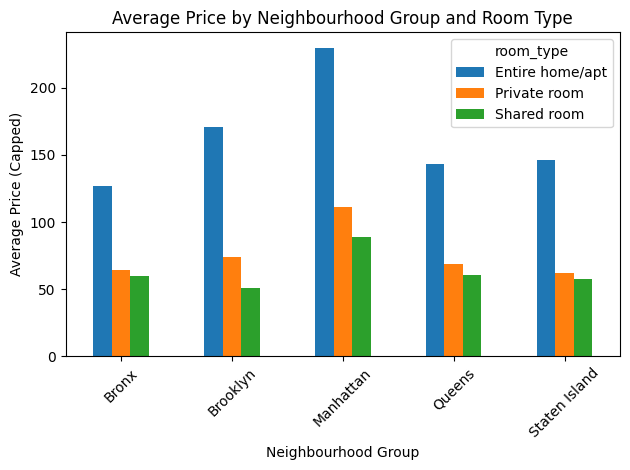

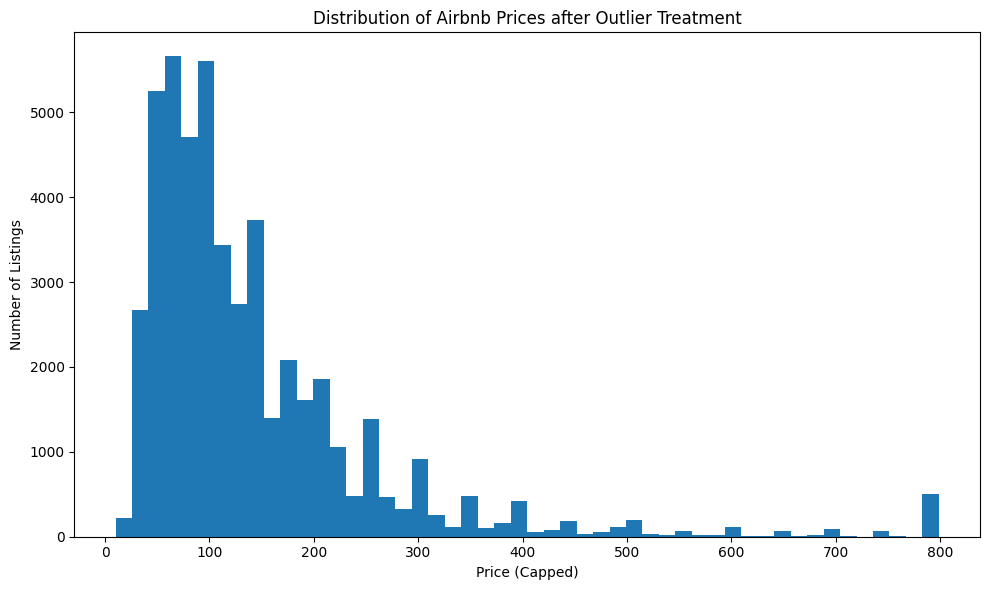

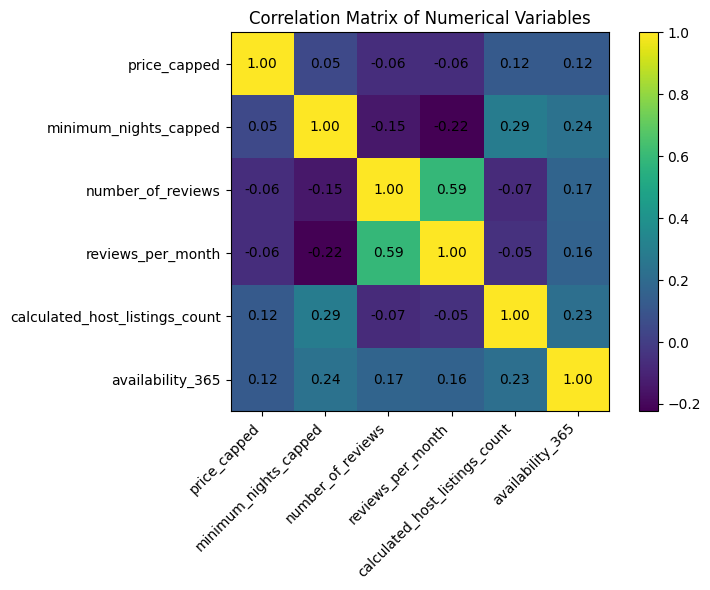


Correlation matrix:


,price_capped,minimum_nights_capped,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
price_capped,1.000000,0.048470,-0.063944,-0.064725,0.122311,0.123229
minimum_nights_capped,0.048470,1.000000,-0.146455,-0.223307,0.290291,0.239035
number_of_reviews,-0.063944,-0.146455,1.000000,0.589311,-0.072385,0.171975
reviews_per_month,-0.064725,-0.223307,0.589311,1.000000,-0.047322,0.163664
calculated_host_listings_count,0.122311,0.290291,-0.072385,-0.047322,1.000000,0.225712
availability_365,0.123229,0.239035,0.171975,0.163664,0.225712,1.000000



Random Forest Regression Results:
MAE: 55.69
RMSE: 96.5
R²: 0.372

Top feature importances:


,feature,importance
9,room_type_Private room,0.386442
4,availability_365,0.145520
6,neighbourhood_group_Manhattan,0.106630
0,minimum_nights_capped,0.089104
3,calculated_host_listings_count,0.076310
2,reviews_per_month,0.070767
1,number_of_reviews,0.063055
10,room_type_Shared room,0.051545
5,neighbourhood_group_Brooklyn,0.008565
7,neighbourhood_group_Queens,0.001931


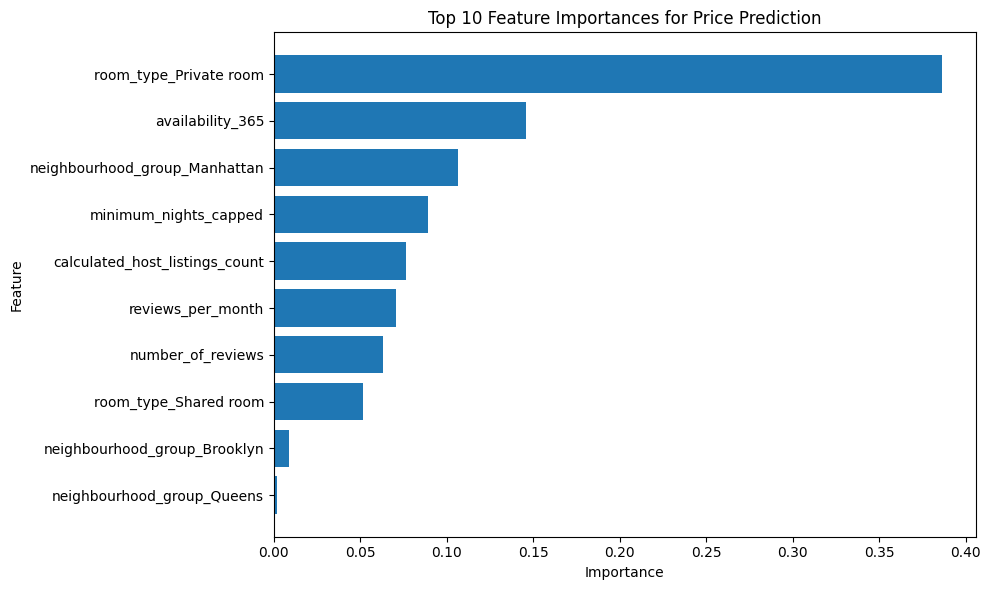

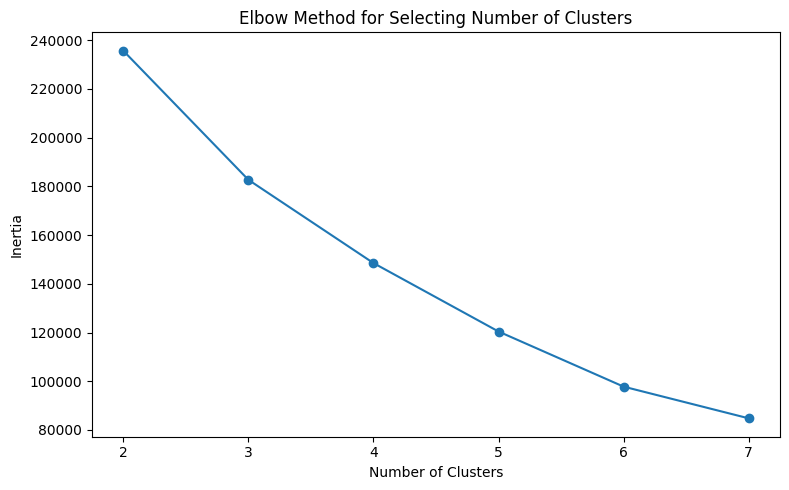


Cluster summary:


,listing_count,avg_price,avg_availability,avg_reviews,avg_reviews_per_month,avg_minimum_nights,avg_host_listings
cluster,,,,,,,
0,34063,144.77,76.63,8.96,0.54,3.28,1.85
1,9162,127.69,178.13,86.35,3.61,2.19,2.21
2,5100,153.81,218.28,7.84,0.30,30.54,20.65
3,559,273.93,281.70,2.34,0.72,20.45,287.57


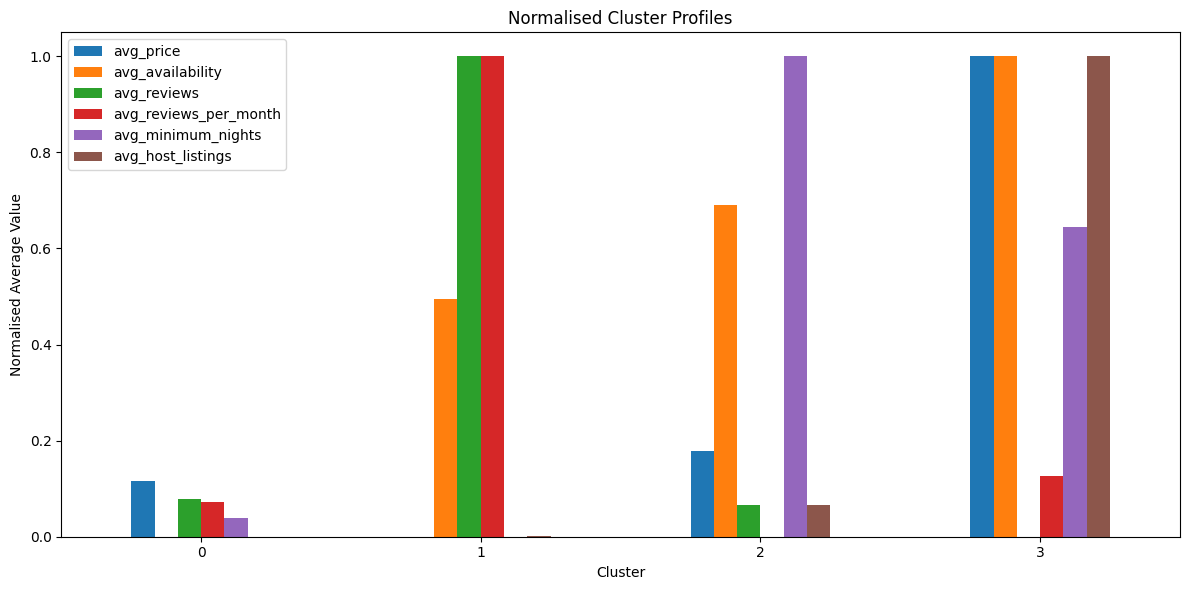


Files exported:
- feature_importance.csv
- cluster_summary.csv


In [3]:
# ============================================================
# Airbnb NYC 2019 - Track 1 Classical ML Analysis
# Business Question:
# How can Airbnb use listing characteristics to predict price
# and identify strategic listing segments in New York City?
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------

# Option A: Upload AB_NYC_2019.csv manually into Colab
df = pd.read_csv("AB_NYC_2019.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst five rows:")
display(df.head())

print("\nMissing values:")
display(df.isnull().sum())

# ------------------------------------------------------------
# 2. Basic preprocessing
# ------------------------------------------------------------

# Fill missing reviews_per_month with 0
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

# Remove listings with price <= 0
df = df[df["price"] > 0].copy()

# Cap extreme values to reduce distortion
price_cap = df["price"].quantile(0.99)
min_nights_cap = df["minimum_nights"].quantile(0.99)

df["price_capped"] = df["price"].clip(upper=price_cap)
df["minimum_nights_capped"] = df["minimum_nights"].clip(upper=min_nights_cap)

print("Price 99th percentile cap:", price_cap)
print("Minimum nights 99th percentile cap:", min_nights_cap)
print("Cleaned dataset shape:", df.shape)

# ------------------------------------------------------------
# 3. Exploratory Data Analysis visuals
# ------------------------------------------------------------

# Figure 1: Average price by neighbourhood group and room type
avg_price = (
    df.groupby(["neighbourhood_group", "room_type"])["price_capped"]
    .mean()
    .reset_index()
)

pivot_avg_price = avg_price.pivot(
    index="neighbourhood_group",
    columns="room_type",
    values="price_capped"
)

plt.figure(figsize=(10, 6))
pivot_avg_price.plot(kind="bar")
plt.title("Average Price by Neighbourhood Group and Room Type")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price (Capped)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Figure 2: Price distribution after capping outliers
plt.figure(figsize=(10, 6))
plt.hist(df["price_capped"], bins=50)
plt.title("Distribution of Airbnb Prices after Outlier Treatment")
plt.xlabel("Price (Capped)")
plt.ylabel("Number of Listings")
plt.tight_layout()
plt.show()

# Figure 3: Correlation heatmap-like matrix
numeric_cols = [
    "price_capped",
    "minimum_nights_capped",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix of Numerical Variables")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

print("\nCorrelation matrix:")
display(corr)

# ------------------------------------------------------------
# 4. Regression model - Predict price
# ------------------------------------------------------------

regression_features = [
    "neighbourhood_group",
    "room_type",
    "minimum_nights_capped",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

X = df[regression_features]
y = df["price_capped"]

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=["neighbourhood_group", "room_type"], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nRandom Forest Regression Results:")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 3))

# Feature importance
feature_importance = pd.DataFrame({
    "feature": X_encoded.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nTop feature importances:")
display(feature_importance.head(10))

plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10).sort_values("importance")
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 10 Feature Importances for Price Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. K-means clustering - Strategic listing segments
# ------------------------------------------------------------

cluster_features = [
    "price_capped",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "minimum_nights_capped",
    "calculated_host_listings_count"
]

cluster_df = df[cluster_features].copy()

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_df)

# Elbow method
inertia = []
k_values = range(2, 8)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(cluster_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker="o")
plt.title("Elbow Method for Selecting Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

# Use 4 clusters for business interpretability
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(cluster_scaled)

cluster_summary = df.groupby("cluster").agg(
    listing_count=("id", "count"),
    avg_price=("price_capped", "mean"),
    avg_availability=("availability_365", "mean"),
    avg_reviews=("number_of_reviews", "mean"),
    avg_reviews_per_month=("reviews_per_month", "mean"),
    avg_minimum_nights=("minimum_nights_capped", "mean"),
    avg_host_listings=("calculated_host_listings_count", "mean")
).round(2)

print("\nCluster summary:")
display(cluster_summary)

# Add suggested business labels manually after viewing cluster summary
# For now, this shows raw cluster numbers.

# Figure 5: Cluster profile chart
cluster_profile = cluster_summary[
    [
        "avg_price",
        "avg_availability",
        "avg_reviews",
        "avg_reviews_per_month",
        "avg_minimum_nights",
        "avg_host_listings"
    ]
]

# Normalise for visual comparison
cluster_profile_norm = (
    cluster_profile - cluster_profile.min()
) / (
    cluster_profile.max() - cluster_profile.min()
)

cluster_profile_norm.plot(kind="bar", figsize=(12, 6))
plt.title("Normalised Cluster Profiles")
plt.xlabel("Cluster")
plt.ylabel("Normalised Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Export useful tables if needed
# ------------------------------------------------------------

feature_importance.to_csv("feature_importance.csv", index=False)
cluster_summary.to_csv("cluster_summary.csv")

print("\nFiles exported:")
print("- feature_importance.csv")
print("- cluster_summary.csv")

Linear Regression Baseline Results:
MAE: 61.25
RMSE: 103.16
R²: 0.283

Random Forest Results for Comparison:
MAE: 55.69
RMSE: 96.5
R²: 0.372

Model comparison:


,Model,MAE,RMSE,R2
0,Linear Regression,61.251,103.159,0.283
1,Random Forest,55.687,96.499,0.372



Silhouette scores:


,k,silhouette_score
0,2,0.465
1,3,0.398
2,4,0.415
3,5,0.404
4,6,0.406
5,7,0.417


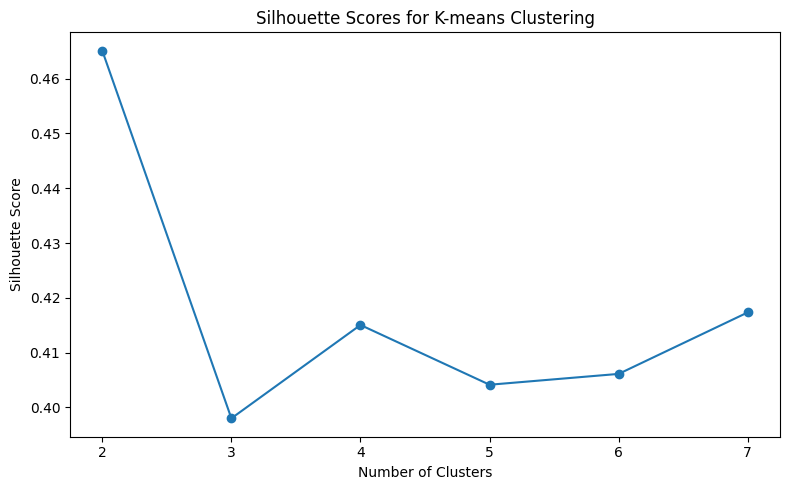

In [4]:
# ============================================================
# Optional Enhancement: Linear Regression Baseline
# and Silhouette Score for K-means Validation
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Linear Regression Baseline
# ------------------------------------------------------------

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression Baseline Results:")
print("MAE:", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²:", round(linear_r2, 3))

print("\nRandom Forest Results for Comparison:")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 3))

comparison_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, mae],
    "RMSE": [linear_rmse, rmse],
    "R2": [linear_r2, r2]
}).round(3)

print("\nModel comparison:")
display(comparison_results)

# ------------------------------------------------------------
# 2. Silhouette Scores for K-means
# ------------------------------------------------------------

silhouette_results = []

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(cluster_scaled)
    score = silhouette_score(cluster_scaled, labels)
    silhouette_results.append({
        "k": k,
        "silhouette_score": score
    })

silhouette_df = pd.DataFrame(silhouette_results)

print("\nSilhouette scores:")
display(silhouette_df.round(3))

plt.figure(figsize=(8, 5))
plt.plot(
    silhouette_df["k"],
    silhouette_df["silhouette_score"],
    marker="o"
)
plt.title("Silhouette Scores for K-means Clustering")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

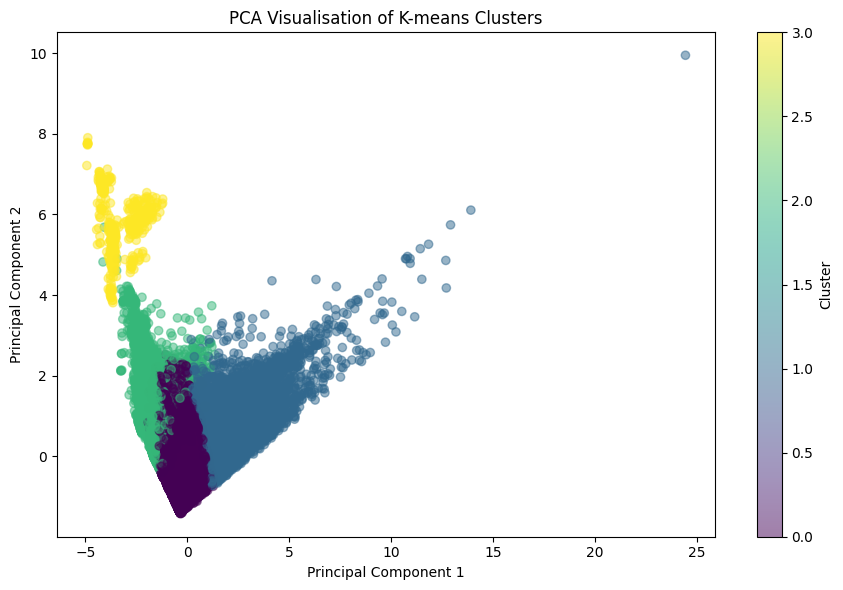

Explained variance ratio: [0.2937228 0.2534379]
Total explained variance: 0.5471606999462022


In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce clustered data to 2 dimensions
pca = PCA(n_components=2, random_state=42)
cluster_pca = pca.fit_transform(cluster_scaled)

# Plot clusters
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    cluster_pca[:, 0],
    cluster_pca[:, 1],
    c=df["cluster"],
    alpha=0.5
)
plt.title("PCA Visualisation of K-means Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())